### 2데이터

MLPRegressor 2023년 데이터의 MSE: 602875.5452884757
MLPRegressor 2023년 데이터의 MAE: 510.2248404052786


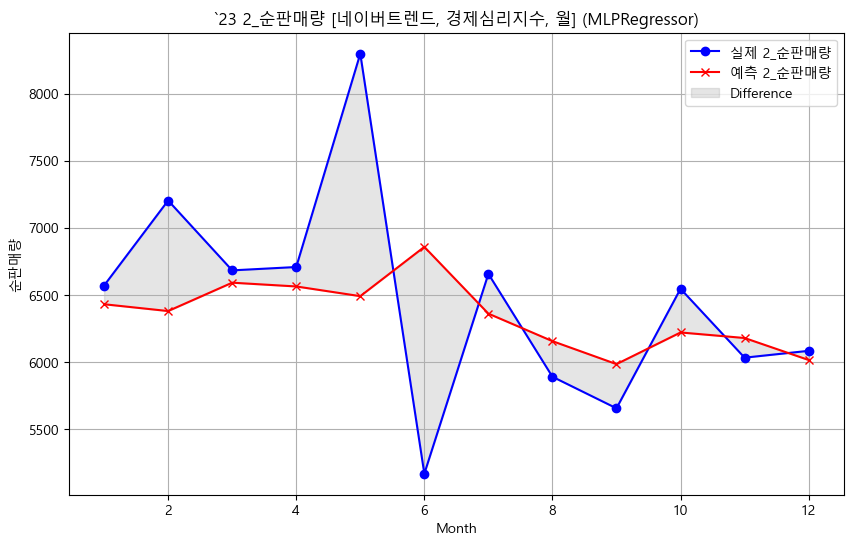

In [9]:
import pandas as pd
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 1. 데이터 불러오기 및 '날짜' 열에서 연도-월 정보 처리
file_path = r"../data/최종 변수.csv"
df = pd.read_csv(file_path)
df['날짜'] = df['날짜'].str[:7]  # '날짜'에서 연도-월까지만 남김
df['월'] = pd.to_datetime(df['날짜']).dt.month  # 월 변수 추가

# 2. 원핫 인코딩 (One-Hot Encoding) 적용
df = pd.get_dummies(df, columns=['월'], drop_first=True)  # 원핫 인코딩 수행, 첫 번째 월은 제외

# 중복된 열이 있는지 확인하고, 중복된 열이 있으면 제거
df = df.loc[:, ~df.columns.duplicated()]  # 중복된 열 제거

# 3. '날짜' 열을 사용하여 2021년과 2022년 데이터만 학습에 사용하고 2023년 데이터는 예측에 사용
df_21_22 = df[df['날짜'].str[:4].isin(['2021', '2022'])] 
df_21_23 = df[df['날짜'].str[:4].isin(['2021', '2022', '2023'])] 
df_23_24 = df[df['날짜'].str[:4].isin(['2023', '2024'])] 
df_23 = df[df['날짜'].str[:4].eq('2023')] 
df_24 = df[df['날짜'].str[:4].eq('2024')] 

# 각 데이터셋에서도 중복된 열 제거
df_21_22 = df_21_22.loc[:, ~df_21_22.columns.duplicated()]
df_21_23 = df_21_23.loc[:, ~df_21_23.columns.duplicated()]
df_23_24 = df_23_24.loc[:, ~df_23_24.columns.duplicated()]
df_23 = df_23.loc[:, ~df_23.columns.duplicated()]
df_24 = df_24.loc[:, ~df_24.columns.duplicated()]
df_train_21_22, df_test_2023, df_test_2024 = df_21_22, df_23, df_24  # 데이터 1 노트북(05)과 같은 이름으로 사용

# 4. 독립 변수 (X)와 종속 변수 (y) 설정
# 원핫 인코딩된 '월' 변수를 포함하여 학습
X_21_22 = df_21_22[['네이버트렌드', '경제심리지수'] + [col for col in df_train_21_22.columns if '월_' in col]]
y_21_22 = df_21_22['2_순판매량']

X_21_23 = df_21_23[['네이버트렌드', '경제심리지수'] + [col for col in df_train_21_22.columns if '월_' in col]]
y_21_23 = df_21_23['2_순판매량']

X_23 = df_23[['네이버트렌드', '경제심리지수'] + [col for col in df_test_2023.columns if '월_' in col]]
y_23 = df_23['2_순판매량']

X_24 = df_24[['네이버트렌드', '경제심리지수'] + [col for col in df_test_2024.columns if '월_' in col]]

X_23_24 = df_23_24[['네이버트렌드', '경제심리지수'] + [col for col in df_test_2024.columns if '월_' in col]]

# 5. MLPRegressor 모델 설정 및 학습
mlp_model_21_22 = MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=500, random_state=42)
mlp_model_21_22.fit(X_21_22, y_21_22)

# 6. 2023년 데이터 예측
mlp_pred_2023 = mlp_model_21_22.predict(X_23)

mlp_pred_23_24 = mlp_model_21_22.predict(X_23_24)

mlp_model_21_23 = MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=500, random_state=42)
mlp_model_21_23.fit(X_21_23, y_21_23)

mlp_pred_24 = mlp_model_21_23.predict(X_24)


# 7. 성능 평가: MSE와 MAE 계산
mlp_mse = mean_squared_error(y_23, mlp_pred_2023)
mlp_mae = mean_absolute_error(y_23, mlp_pred_2023)
print(f"MLPRegressor 2023년 데이터의 MSE: {mlp_mse}")
print(f"MLPRegressor 2023년 데이터의 MAE: {mlp_mae}")

# 8. 실제값과 비교
if '2_순판매량' in df_23.columns:
    actual_2023 = df_23['2_순판매량'].values
else:
    actual_2023 = None
    print("2023년 데이터에 대한 실제값이 없으므로, 비교할 수 없습니다.")

# 9. 그래프 그리기
if actual_2023 is not None:
    months_2023 = np.arange(1, len(actual_2023) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(months_2023, actual_2023, label='실제 2_순판매량', marker='o', color='b')
    plt.plot(months_2023, mlp_pred_2023, label='예측 2_순판매량', marker='x', color='r')
    plt.fill_between(months_2023, actual_2023, mlp_pred_2023, color='gray', alpha=0.2, label='Difference')

    plt.xlabel('Month')
    plt.ylabel('순판매량')
    plt.title('`23 2_순판매량 [네이버트렌드, 경제심리지수, 월] (MLPRegressor)')
    plt.legend()
    plt.grid(True)
    plt.show()

In [7]:
mlp_pred_23_24

array([6431.81153197, 6381.10185078, 6592.28194097, 6564.23153962,
       6491.94157227, 6858.86250694, 6361.87357127, 6157.08252495,
       5985.93125846, 6221.67001566, 6180.47484293, 6016.74102588,
       6002.46824012, 5820.67534496, 5964.79370194, 6095.98459569,
       6056.65844399, 5912.10017722])

In [10]:
mlp_pred_24

array([6052.03214693, 5870.85755589, 6013.69720359, 6147.72802404,
       6109.4580494 , 5958.71545008])

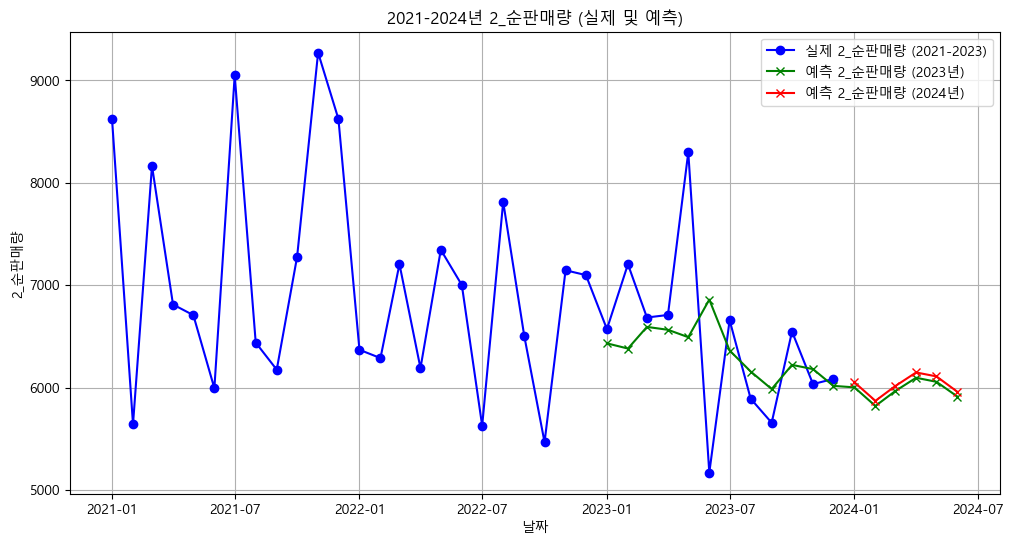

In [15]:
# 1. 2021~2023년 실제 데이터 추출 (2_순판매량으로 변경)
df_train_21_23 = df[df['날짜'].str[:4].isin(['2021', '2022', '2023'])]  # 학습 데이터: 2021년, 2022년, 2023년

# 날짜 및 2_순판매량 추출
dates_train = pd.to_datetime(df_train_21_23['날짜'])
sales_train = df_train_21_23['2_순판매량']

# 2. 2023년 예측 데이터 준비 (MLPRegressor 결과 사용)
dates_test_2023_24 = pd.to_datetime(df_23_24['날짜'])
sales_pred_2023_24 = mlp_pred_23_24  # MLP 모델에서 예측한 2023년 결과

# 3. 2024년 예측 데이터 준비 (MLPRegressor 결과 사용)
dates_test_2024 = pd.to_datetime(df_test_2024['날짜'])
sales_pred_2024 = mlp_pred_24  # MLP 모델에서 예측한 2024년 결과

# 4. 그래프 그리기
plt.figure(figsize=(12, 6))

# 2021~2023년 실제 데이터 그래프
plt.plot(dates_train, sales_train, label='실제 2_순판매량 (2021-2023)', marker='o', color='b')

# 2023년 예측 데이터 그래프
plt.plot(dates_test_2023_24, sales_pred_2023_24, label='예측 2_순판매량 (2023년)', marker='x', color='g')

# 2024년 예측 데이터 그래프
plt.plot(dates_test_2024, sales_pred_2024, label='예측 2_순판매량 (2024년)', marker='x', color='r')

# 그래프 설정
plt.xlabel('날짜')
plt.ylabel('2_순판매량')
plt.title('2021-2024년 2_순판매량 (실제 및 예측)')
plt.legend()
plt.grid(True)

# 그래프 표시
plt.show()


MLPRegressor MSE: 602875.5452884756
MLPRegressor MAE: 510.2248404052787
CatBoostRegressor MSE: 1374518.2285164355
CatBoostRegressor MAE: 1001.0967157665976
RandomForestRegressor MSE: 920096.5859250001
RandomForestRegressor MAE: 761.6775000000001
XGBRegressor MSE: 1344350.4943045974
XGBRegressor MAE: 993.3997802734375


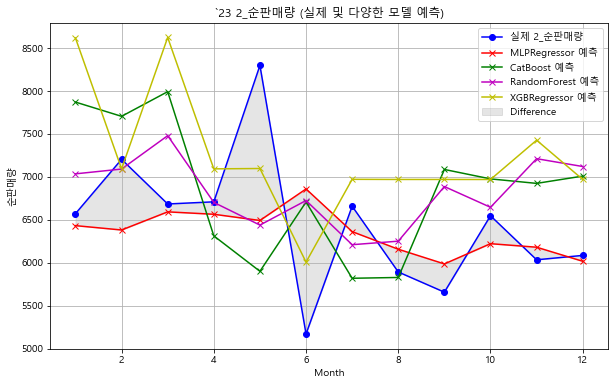

In [39]:
import pandas as pd
from sklearn.neural_network import MLPRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 불러오기 및 '날짜' 열에서 연도-월 정보 처리
df = pd.read_csv('../data/최종 변수.csv')
df['날짜'] = df['날짜'].str[:7]  # '날짜'에서 연도-월까지만 남김
df['월'] = pd.to_datetime(df['날짜']).dt.month  # 월 변수 추가

# 2. 원핫 인코딩 (One-Hot Encoding) 적용
df = pd.get_dummies(df, columns=['월'], drop_first=True)  # 원핫 인코딩 수행

# 3. 학습 데이터와 테스트 데이터 분리
df_train = df[df['날짜'].str[:4].isin(['2021', '2022'])]  # 학습 데이터
df_2023 = df[df['날짜'].str[:4].eq('2023')]  # 테스트 데이터

# 4. 독립 변수 (X)와 종속 변수 (y) 설정
X_train = df_train[['네이버트렌드', '경제심리지수'] + [col for col in df_train.columns if '월_' in col]]
y_train = df_train['2_순판매량']
X_test = df_2023[['네이버트렌드', '경제심리지수'] + [col for col in df_2023.columns if '월_' in col]]
y_test = df_2023['2_순판매량']

# 5. 각 모델 설정 및 학습
mlp_model = MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=500, random_state=42)
mlp_model.fit(X_train, y_train)

catboost_model = CatBoostRegressor(verbose=0)
catboost_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

# 6. 각 모델로 예측
mlp_pred = mlp_model.predict(X_test)
catboost_pred = catboost_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# 7. 성능 평가: MSE와 MAE 계산
models = ['MLPRegressor', 'CatBoostRegressor', 'RandomForestRegressor', 'XGBRegressor']
preds = [mlp_pred, catboost_pred, rf_pred, xgb_pred]

for model, pred in zip(models, preds):
    mse = mean_squared_error(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    print(f"{model} MSE: {mse}")
    print(f"{model} MAE: {mae}")

# 8. 그래프 그리기
months_2023 = np.arange(1, len(y_test) + 1)

plt.figure(figsize=(10, 6))
plt.plot(months_2023, y_test, label='실제 2_순판매량', marker='o', color='b')

# 모델별 예측 결과 그래프
plt.plot(months_2023, mlp_pred, label='MLPRegressor 예측', marker='x', color='r')
plt.plot(months_2023, catboost_pred, label='CatBoost 예측', marker='x', color='g')
plt.plot(months_2023, rf_pred, label='RandomForest 예측', marker='x', color='m')
plt.plot(months_2023, xgb_pred, label='XGBRegressor 예측', marker='x', color='y')

plt.fill_between(months_2023, y_test, mlp_pred, color='gray', alpha=0.2, label='Difference')

plt.xlabel('Month')
plt.ylabel('순판매량')
plt.title('`23 2_순판매량 (실제 및 다양한 모델 예측)')
plt.legend()
plt.grid(True)
plt.show()